In [1]:
# If sklearn isn't available, uncomment:
# !pip install scikit-learn

import os, json, math
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from datetime import datetime


In [2]:
import os
from pathlib import Path

# === Project root detection (safe even if run from scripts/) ===
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path.cwd().parent
# If you are running in Jupyter inside "scripts", it will correctly go one level up to "Solarcast"

# === Project paths ===
DATA_DIR = PROJECT_ROOT / "data"
ART_DIR  = PROJECT_ROOT / "artifacts"

RAW_PATH   = DATA_DIR / "wholedata.csv"
CLEAN_PATH = DATA_DIR / "solar_data_clean.csv"
MODEL_PATH = DATA_DIR / "solar_data_model.csv"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

# Create directories if missing
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(ART_DIR, exist_ok=True)

print(f"📂 Data directory: {DATA_DIR}")
print(f"📄 Raw data path: {RAW_PATH}")

# === Site / physics ===
PLANT_KW = 5000         # 5 MW site
EFFICIENCY = 0.20       # overall DC→AC proxy
DAY_IRR_THRESHOLD = 30.0  # W/m² - daytime cutoff for modeling & MAPE

# === Flexible renaming map (handles Visual Crossing variants) ===
RENAME_MAP = {
    "period_en": "datetime", "Date time": "datetime",
    "ghi": "irradiance", "GHI": "irradiance",
    "air_temp": "temp", "AIR_TEMP": "temp",
    "relative_h": "humidity", "RELATIVE_HUMIDITY": "humidity",
    "cloud_opa": "cloud_cover", "CLOUD_OPACITY": "cloud_cover"
}

# === Keep lists ===
KEEP_BASE = ["datetime", "irradiance", "temp", "humidity", "cloud_cover"]
KEEP_OPTIONAL = ["dewpoint_dni", "surface_pr", "wind_spee", "zenith", 
                 "DNI", "DHI", "pressure", "wind_speed_10m"]

# === Feature engineering params ===
LAG_STEPS    = [1, 2]   # 1=15min, 2=30min back
ROLL_WINDOWS = [3, 5]   # 45 & 75 minutes if 15-min data
TRAIN_RATIO  = 0.8

print("✅ Paths configured successfully!")


📂 Data directory: D:\DMBI\Solarcast\data
📄 Raw data path: D:\DMBI\Solarcast\data\wholedata.csv
✅ Paths configured successfully!


In [3]:
df = pd.read_csv(RAW_PATH)

# Apply renames if present
df = df.rename(columns={k:v for k,v in RENAME_MAP.items() if k in df.columns})

# Ensure datetime column exists
if "datetime" not in df.columns:
    raise ValueError("No datetime column found. Provide 'datetime' or a column like 'period_en' / 'Date time'.")

# Parse & tidy time
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=False)
df = df.dropna(subset=["datetime"]).sort_values("datetime").drop_duplicates(subset=["datetime"], keep="first")

# Keep only relevant columns (whatever exists)
keep_cols = ["datetime"] + [c for c in KEEP_BASE + KEEP_OPTIONAL if c in df.columns and c != "datetime"]
df = df[keep_cols]

# Cast numerics
for c in df.columns:
    if c != "datetime":
        df[c] = pd.to_numeric(df[c], errors="coerce")

print(df.head())
print("Columns:", list(df.columns))
print("Rows:", len(df))


                   datetime  irradiance  temp  humidity  cloud_cover  zenith  \
0 2025-01-01 00:15:00+05:00           0    23      68.3          0.0     175   
1 2025-01-01 00:30:00+05:00           0    22      68.6          0.0     171   
2 2025-01-01 00:45:00+05:00           0    22      69.0          0.0     168   
3 2025-01-01 01:00:00+05:00           0    22      69.4          0.0     165   
4 2025-01-01 01:15:00+05:00           0    22      69.7          0.0     161   

   wind_speed_10m  
0             1.9  
1             2.1  
2             2.3  
3             2.5  
4             2.7  
Columns: ['datetime', 'irradiance', 'temp', 'humidity', 'cloud_cover', 'zenith', 'wind_speed_10m']
Rows: 28224


## Finding Missing values

In [4]:
print("Finding the Missing values:")
print(df.isnull().sum())

Finding the Missing values:
datetime          0
irradiance        0
temp              0
humidity          0
cloud_cover       0
zenith            0
wind_speed_10m    0
dtype: int64


## Adding target Feature (Power) to our dataframe

In [5]:
# Ensure irradiance exists (Visual Crossing should provide it; else default to 0)
if "irradiance" not in df.columns:
    df["irradiance"] = 0.0

# Power (kW) = irradiance (W/m²) × plant_kW × efficiency / 1000
df["actual_power_kW"] = (df["irradiance"] * PLANT_KW * EFFICIENCY) / 1000.0
df["actual_power_kW"] = df["actual_power_kW"].clip(lower=0, upper=PLANT_KW)

print(df[["datetime", "irradiance", "actual_power_kW"]].head())


                   datetime  irradiance  actual_power_kW
0 2025-01-01 00:15:00+05:00           0              0.0
1 2025-01-01 00:30:00+05:00           0              0.0
2 2025-01-01 00:45:00+05:00           0              0.0
3 2025-01-01 01:00:00+05:00           0              0.0
4 2025-01-01 01:15:00+05:00           0              0.0


In [6]:
# Calendar & cyclical time features
df["hour"] = df["datetime"].dt.hour
df["minute"] = df["datetime"].dt.minute
df["dayofyear"] = df["datetime"].dt.dayofyear
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)

# Lags & rolling means on key drivers
for col in ["irradiance", "temp"]:
    if col in df.columns:
        for lag in LAG_STEPS:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
        for w in ROLL_WINDOWS:
            df[f"{col}_roll{w}"] = df[col].rolling(window=w, min_periods=1).mean()

# Drop rows made NaN by lagging
df = df.dropna().reset_index(drop=True)
print("✅ After feature engineering, rows:", len(df))
df.head()


✅ After feature engineering, rows: 28222


,datetime,irradiance,temp,humidity,cloud_cover,zenith,wind_speed_10m,actual_power_kW,hour,minute,...,hour_sin,hour_cos,irradiance_lag1,irradiance_lag2,irradiance_roll3,irradiance_roll5,temp_lag1,temp_lag2,temp_roll3,temp_roll5
0,2025-01-01 00:45:00+05:00,0,22,69.0,0.0,168,2.3,0.0,0,45,...,0.000000,1.000000,0.0,0.0,0.0,0.0,22.0,23.0,22.333333,22.333333
1,2025-01-01 01:00:00+05:00,0,22,69.4,0.0,165,2.5,0.0,1,0,...,0.258819,0.965926,0.0,0.0,0.0,0.0,22.0,22.0,22.000000,22.250000
2,2025-01-01 01:15:00+05:00,0,22,69.7,0.0,161,2.7,0.0,1,15,...,0.258819,0.965926,0.0,0.0,0.0,0.0,22.0,22.0,22.000000,22.200000
3,2025-01-01 01:30:00+05:00,0,21,69.9,13.4,158,2.8,0.0,1,30,...,0.258819,0.965926,0.0,0.0,0.0,0.0,22.0,22.0,21.666667,21.800000
4,2025-01-01 01:45:00+05:00,0,21,70.1,23.5,154,2.9,0.0,1,45,...,0.258819,0.965926,0.0,0.0,0.0,0.0,21.0,22.0,21.333333,21.600000


## Finding outliers and removing it by replacing it with LB and UB

In [7]:
# --- Outlier Detection and Capping (IQR) ---

features = ["irradiance", "temp", "humidity", "cloud_cover"]

print("Before outlier treatment:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

for feature in features:
    if feature in df.columns:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        UB = Q3 + 1.5 * IQR
        LB = Q1 - 1.5 * IQR
        
        print(f"\n🔹 Feature: {feature}")
        print(f"   IQR = {IQR:.2f}")
        print(f"   Upper Bound = {UB:.2f}, Lower Bound = {LB:.2f}")
        
        # Cap outliers (replace extreme values with UB/LB)
        df[feature] = df[feature].apply(
            lambda x: UB if x > UB else (LB if x < LB else x)
        )

print("\n✅ Outlier capping applied successfully for selected features.")
print(f"After outlier treatment: Rows = {df.shape[0]}, Columns = {df.shape[1]}")


Before outlier treatment:
Rows: 28222, Columns: 21

🔹 Feature: irradiance
   IQR = 363.75
   Upper Bound = 909.38, Lower Bound = -545.62

🔹 Feature: temp
   IQR = 5.00
   Upper Bound = 38.50, Lower Bound = 18.50

🔹 Feature: humidity
   IQR = 38.90
   Upper Bound = 142.05, Lower Bound = -13.55

🔹 Feature: cloud_cover
   IQR = 63.50
   Upper Bound = 158.75, Lower Bound = -95.25

✅ Outlier capping applied successfully for selected features.
After outlier treatment: Rows = 28222, Columns = 21


## Daytime Filter & Save Clean CSV

In [8]:
# Keep daytime only to avoid night-time MAPE distortion
DAY_IRR_THRESHOLD = DAY_IRR_THRESHOLD  # already defined above
df_day = df[df["irradiance"] >= DAY_IRR_THRESHOLD].copy().reset_index(drop=True)

# Drop Visual Crossing's 'period' column if present
if "period" in df_day.columns:
    df_day = df_day.drop(columns=["period"])

# Save clean, engineered (daytime) dataset
df_day.to_csv(CLEAN_PATH, index=False)
print(f"✅ Saved cleaned daytime dataset → {CLEAN_PATH} | rows: {len(df_day)}")
df_day.head()


✅ Saved cleaned daytime dataset → D:\DMBI\Solarcast\data\solar_data_clean.csv | rows: 13390


,datetime,irradiance,temp,humidity,cloud_cover,zenith,wind_speed_10m,actual_power_kW,hour,minute,...,hour_sin,hour_cos,irradiance_lag1,irradiance_lag2,irradiance_roll3,irradiance_roll5,temp_lag1,temp_lag2,temp_roll3,temp_roll5
0,2025-01-01 07:00:00+05:00,50.0,19.0,68.8,0.0,84,2.6,50.0,7,0,...,0.965926,-0.258819,20.0,1.0,23.666667,14.2,20.0,20.0,19.666667,19.8
1,2025-01-01 07:15:00+05:00,87.0,19.0,69.0,0.0,81,2.7,87.0,7,15,...,0.965926,-0.258819,50.0,20.0,52.333333,31.6,19.0,20.0,19.333333,19.6
2,2025-01-01 07:30:00+05:00,130.0,19.0,69.7,0.0,78,2.8,130.0,7,30,...,0.965926,-0.258819,87.0,50.0,89.000000,57.6,19.0,19.0,19.000000,19.4
3,2025-01-01 07:45:00+05:00,176.0,19.0,70.3,0.0,75,2.8,176.0,7,45,...,0.965926,-0.258819,130.0,87.0,131.000000,92.6,19.0,19.0,19.000000,19.2
4,2025-01-01 08:00:00+05:00,225.0,19.0,71.0,0.0,72,2.9,225.0,8,0,...,0.866025,-0.500000,176.0,130.0,177.000000,133.6,19.0,19.0,19.000000,19.0


    ## Scale Features & Build Model Matrix

In [9]:
# A model matrix is the numerical representation of all your input features (independent variables) used by a machine learning or statistical model.

# It’s the 2-D table or array where:

# Rows = observations / samples

# Columns = features / variables

# So if you have 
# 𝑛
# n samples and 
# 𝑝
# p features,
# your model matrix has shape = (n, p).

In [10]:
import json

# Exclude datetime and target column
exclude = {"datetime", "actual_power_kW"}
feature_cols = [c for c in df_day.columns if c not in exclude]

# Just make a clean version for modeling (no scaling)
df_model = df_day[["datetime"] + feature_cols + ["actual_power_kW"]].copy()

# Save the file for model training phase
df_model.to_csv(MODEL_PATH, index=False)

# Save the feature list (helps in later training/prediction)
with open(ART_DIR / "feature_cols.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print(f"✅ Saved clean model dataset → {MODEL_PATH}")
print(f"Total features used: {len(feature_cols)}")
print("First few features:", feature_cols[:6])
df_model.head()


✅ Saved clean model dataset → D:\DMBI\Solarcast\data\solar_data_model.csv
Total features used: 19
First few features: ['irradiance', 'temp', 'humidity', 'cloud_cover', 'zenith', 'wind_speed_10m']


,datetime,irradiance,temp,humidity,cloud_cover,zenith,wind_speed_10m,hour,minute,dayofyear,...,hour_cos,irradiance_lag1,irradiance_lag2,irradiance_roll3,irradiance_roll5,temp_lag1,temp_lag2,temp_roll3,temp_roll5,actual_power_kW
0,2025-01-01 07:00:00+05:00,50.0,19.0,68.8,0.0,84,2.6,7,0,1,...,-0.258819,20.0,1.0,23.666667,14.2,20.0,20.0,19.666667,19.8,50.0
1,2025-01-01 07:15:00+05:00,87.0,19.0,69.0,0.0,81,2.7,7,15,1,...,-0.258819,50.0,20.0,52.333333,31.6,19.0,20.0,19.333333,19.6,87.0
2,2025-01-01 07:30:00+05:00,130.0,19.0,69.7,0.0,78,2.8,7,30,1,...,-0.258819,87.0,50.0,89.000000,57.6,19.0,19.0,19.000000,19.4,130.0
3,2025-01-01 07:45:00+05:00,176.0,19.0,70.3,0.0,75,2.8,7,45,1,...,-0.258819,130.0,87.0,131.000000,92.6,19.0,19.0,19.000000,19.2,176.0
4,2025-01-01 08:00:00+05:00,225.0,19.0,71.0,0.0,72,2.9,8,0,1,...,-0.500000,176.0,130.0,177.000000,133.6,19.0,19.0,19.000000,19.0,225.0


## Time-based Train/Test Split (80/20)

In [11]:
n = len(df_model)
cut = int(n * TRAIN_RATIO)
train = df_model.iloc[:cut].copy()
test  = df_model.iloc[cut:].copy()

train.to_csv(TRAIN_PATH, index=False)
test.to_csv(TEST_PATH, index=False)

print(f"✅ Train/Test saved → {TRAIN_PATH} / {TEST_PATH}")
print("Train rows:", len(train), "| Test rows:", len(test))
train.head(), test.head()


✅ Train/Test saved → D:\DMBI\Solarcast\data\train.csv / D:\DMBI\Solarcast\data\test.csv
Train rows: 10712 | Test rows: 2678


(                   datetime  irradiance  temp  humidity  cloud_cover  zenith  \
 0 2025-01-01 07:00:00+05:00        50.0  19.0      68.8          0.0      84   
 1 2025-01-01 07:15:00+05:00        87.0  19.0      69.0          0.0      81   
 2 2025-01-01 07:30:00+05:00       130.0  19.0      69.7          0.0      78   
 3 2025-01-01 07:45:00+05:00       176.0  19.0      70.3          0.0      75   
 4 2025-01-01 08:00:00+05:00       225.0  19.0      71.0          0.0      72   
 
    wind_speed_10m  hour  minute  dayofyear  ...  hour_cos  irradiance_lag1  \
 0             2.6     7       0          1  ... -0.258819             20.0   
 1             2.7     7      15          1  ... -0.258819             50.0   
 2             2.8     7      30          1  ... -0.258819             87.0   
 3             2.8     7      45          1  ... -0.258819            130.0   
 4             2.9     8       0          1  ... -0.500000            176.0   
 
    irradiance_lag2  irradiance_roll

## Load train/test CSVs

In [12]:
train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

# --- Split into X (features) and y (target) ---
x_train = train.drop(columns=["actual_power_kW", "datetime"])
y_train = train["actual_power_kW"]

x_test  = test.drop(columns=["actual_power_kW", "datetime"])
y_test  = test["actual_power_kW"]

# --- Display shapes and sample data ---
print("x_train:", x_train.shape, "| x_test:", x_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

display(x_train.head(), y_train.head(), x_test.head(), y_test.head())

x_train: (10712, 19) | x_test: (2678, 19)
y_train: (10712,) | y_test: (2678,)


,irradiance,temp,humidity,cloud_cover,zenith,wind_speed_10m,hour,minute,dayofyear,hour_sin,hour_cos,irradiance_lag1,irradiance_lag2,irradiance_roll3,irradiance_roll5,temp_lag1,temp_lag2,temp_roll3,temp_roll5
0,50.0,19.0,68.8,0.0,84,2.6,7,0,1,0.965926,-0.258819,20.0,1.0,23.666667,14.2,20.0,20.0,19.666667,19.8
1,87.0,19.0,69.0,0.0,81,2.7,7,15,1,0.965926,-0.258819,50.0,20.0,52.333333,31.6,19.0,20.0,19.333333,19.6
2,130.0,19.0,69.7,0.0,78,2.8,7,30,1,0.965926,-0.258819,87.0,50.0,89.000000,57.6,19.0,19.0,19.000000,19.4
3,176.0,19.0,70.3,0.0,75,2.8,7,45,1,0.965926,-0.258819,130.0,87.0,131.000000,92.6,19.0,19.0,19.000000,19.2
4,225.0,19.0,71.0,0.0,72,2.9,8,0,1,0.866025,-0.500000,176.0,130.0,177.000000,133.6,19.0,19.0,19.000000,19.0


0     50.0
1     87.0
2    130.0
3    176.0
4    225.0
Name: actual_power_kW, dtype: float64

,irradiance,temp,humidity,cloud_cover,zenith,wind_speed_10m,hour,minute,dayofyear,hour_sin,hour_cos,irradiance_lag1,irradiance_lag2,irradiance_roll3,irradiance_roll5,temp_lag1,temp_lag2,temp_roll3,temp_roll5
0,39.0,27.0,77.6,54.4,81,4.1,6,15,235,1.000000,6.123234e-17,14.0,3.0,18.666667,11.2,27.0,27.0,27.0,27.0
1,82.0,27.0,77.2,38.1,78,4.1,6,30,235,1.000000,6.123234e-17,39.0,14.0,45.000000,27.6,27.0,27.0,27.0,27.0
2,120.0,27.0,76.9,34.5,74,4.1,6,45,235,1.000000,6.123234e-17,82.0,39.0,80.333333,51.6,27.0,27.0,27.0,27.0
3,145.0,27.0,76.6,38.5,71,4.1,7,0,235,0.965926,-2.588190e-01,120.0,82.0,115.666667,80.0,27.0,27.0,27.0,27.0
4,154.0,27.0,76.6,47.0,67,4.2,7,15,235,0.965926,-2.588190e-01,145.0,120.0,139.666667,108.0,27.0,27.0,27.0,27.0


0     39.0
1     82.0
2    120.0
3    145.0
4    154.0
Name: actual_power_kW, dtype: float64

## Baseline (simple)

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression

# If 'irradiance' exists, use a 1-feature linear baseline; else fallback to train-mean
if "irradiance" in x_train.columns:
    base = LinearRegression()
    base.fit(x_train[["irradiance"]], y_train)
    y_pred_base = base.predict(x_test[["irradiance"]])
    baseline_name = "Baseline: Linear(irradiance)"
else:
    y_pred_base = np.full(len(y_test), float(y_train.mean()))
    baseline_name = "Baseline: Train-mean"

print(baseline_name, "ready.")


Baseline: Linear(irradiance) ready.


## Random Forest (main model)

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_estimators=300, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

print("RandomForest model trained.")


RandomForest model trained.


## Metrics (MAE, RMSE, MAPE)

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rmse_value(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

print("\nBASELINE")
print("MAE :", mean_absolute_error(y_test, y_pred_base))
print("RMSE:", rmse_value(y_test, y_pred_base))
print("MAPE:", mape(y_test, y_pred_base))

print("\nRANDOM FOREST")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse_value(y_test, y_pred))
print("MAPE:", mape(y_test, y_pred))



BASELINE
MAE : 1.3585143253572627
RMSE: 1.656151637013824
MAPE: 0.6438035843229956

RANDOM FOREST
MAE : 0.008495145631064106
RMSE: 0.02384368437428525
MAPE: 0.0018082697660270694


## Save predictions (with datetime from test)

In [16]:
# Build results table (force aligned lengths)
results = pd.DataFrame({
    "datetime": test["datetime"].reset_index(drop=True),
    "actual_power_kW": y_test.reset_index(drop=True),
    "pred_baseline_kW": pd.Series(np.asarray(y_pred_base)).reset_index(drop=True),
    "pred_model_kW": pd.Series(np.asarray(y_pred)).reset_index(drop=True),
})

out_path = DATA_DIR / "forecast_output.csv"
results.to_csv(out_path, index=False)

print("✅ Saved →", out_path.resolve())
results.head()

✅ Saved → D:\DMBI\Solarcast\data\forecast_output.csv


,datetime,actual_power_kW,pred_baseline_kW,pred_model_kW
0,2025-08-23 06:15:00+05:00,39.0,37.492899,39.0
1,2025-08-23 06:30:00+05:00,82.0,80.769459,82.0
2,2025-08-23 06:45:00+05:00,120.0,119.013861,120.0
3,2025-08-23 07:00:00+05:00,145.0,144.174652,145.0
4,2025-08-23 07:15:00+05:00,154.0,153.232537,154.0


## Load the model dataset

In [17]:
MODEL_PATH = DATA_DIR / "solar_data_model.csv"   # from Phase 1

dfm = pd.read_csv(MODEL_PATH)
print(dfm.columns.tolist()[:8], "...")  # quick peek
dfm.head()

['datetime', 'irradiance', 'temp', 'humidity', 'cloud_cover', 'zenith', 'wind_speed_10m', 'hour'] ...


,datetime,irradiance,temp,humidity,cloud_cover,zenith,wind_speed_10m,hour,minute,dayofyear,...,hour_cos,irradiance_lag1,irradiance_lag2,irradiance_roll3,irradiance_roll5,temp_lag1,temp_lag2,temp_roll3,temp_roll5,actual_power_kW
0,2025-01-01 07:00:00+05:00,50.0,19.0,68.8,0.0,84,2.6,7,0,1,...,-0.258819,20.0,1.0,23.666667,14.2,20.0,20.0,19.666667,19.8,50.0
1,2025-01-01 07:15:00+05:00,87.0,19.0,69.0,0.0,81,2.7,7,15,1,...,-0.258819,50.0,20.0,52.333333,31.6,19.0,20.0,19.333333,19.6,87.0
2,2025-01-01 07:30:00+05:00,130.0,19.0,69.7,0.0,78,2.8,7,30,1,...,-0.258819,87.0,50.0,89.000000,57.6,19.0,19.0,19.000000,19.4,130.0
3,2025-01-01 07:45:00+05:00,176.0,19.0,70.3,0.0,75,2.8,7,45,1,...,-0.258819,130.0,87.0,131.000000,92.6,19.0,19.0,19.000000,19.2,176.0
4,2025-01-01 08:00:00+05:00,225.0,19.0,71.0,0.0,72,2.9,8,0,1,...,-0.500000,176.0,130.0,177.000000,133.6,19.0,19.0,19.000000,19.0,225.0


## Build “next-15” target and split

In [18]:
from sklearn.model_selection import train_test_split

# Make next-15 target & timestamp
dfm["target_next15_kW"] = dfm["actual_power_kW"].shift(-1)
dfm["datetime_next15"]  = dfm["datetime"].shift(-1)

# Drop last row (has NaN after shift)
dfm = dfm.dropna().reset_index(drop=True)

# Features = all except these:
drop_cols = {"datetime", "actual_power_kW", "target_next15_kW", "datetime_next15"}
X = dfm.drop(columns=[c for c in drop_cols if c in dfm.columns])
y = dfm["target_next15_kW"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("x_train:", x_train.shape, "| x_test:", x_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)


x_train: (10711, 19) | x_test: (2678, 19)
y_train: (10711,) | y_test: (2678,)


## Baseline + Random Forest (simple)

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Baseline: 1-feature linear on irradiance if available; else train-mean
if "irradiance" in x_train.columns:
    base = LinearRegression().fit(x_train[["irradiance"]], y_train)
    y_pred_base = base.predict(x_test[["irradiance"]])
else:
    y_pred_base = np.full(len(y_test), float(y_train.mean()))

# Model: Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)

print("Models trained.")


Models trained.


## Metrics (MAE, RMSE, MAPE) — version that works on all sklearn

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > eps
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

print("\nBASELINE (next 15 min)")
print("MAE :", mean_absolute_error(y_test, y_pred_base))
print("RMSE:", rmse(y_test, y_pred_base))
print("MAPE:", mape(y_test, y_pred_base))

print("\nRANDOM FOREST (next 15 min)")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse(y_test, y_pred))
print("MAPE:", mape(y_test, y_pred))



BASELINE (next 15 min)
MAE : 36.95354303153547
RMSE: 45.79188892720289
MAPE: 15.740857203796615

RANDOM FOREST (next 15 min)
MAE : 15.36072566591984
RMSE: 28.0071015933568
MAPE: 6.007789053621368


## Cell 19 — Save next-15 predictions with timestamps

In [21]:
# Match each prediction to its target timestamp (the next 15-min point)
results_next15 = pd.DataFrame({
    "datetime_next15": dfm.iloc[x_test.index]["datetime_next15"].reset_index(drop=True),
    "actual_next15_kW": y_test.reset_index(drop=True),
    "pred_baseline_kW": pd.Series(y_pred_base),
    "pred_model_kW":    pd.Series(y_pred)
})

out_path = DATA_DIR / "forecast_output_next15.csv"
results_next15.to_csv(out_path, index=False)
print("✅ Saved →", out_path.resolve())
results_next15.head()


✅ Saved → D:\DMBI\Solarcast\data\forecast_output_next15.csv


,datetime_next15,actual_next15_kW,pred_baseline_kW,pred_model_kW
0,2025-04-06 11:00:00+05:00,963.0,905.600508,949.146667
1,2025-01-14 09:45:00+05:00,366.0,332.627140,370.560000
2,2025-06-13 15:30:00+05:00,379.0,435.655850,424.626667
3,2025-02-09 08:30:00+05:00,358.0,305.879302,363.713333
4,2025-10-09 08:00:00+05:00,383.0,336.589783,389.320000


## Phas 3 (Analyzing the Data)

## Load the saved next-15 forecast

In [23]:
forecast_path = DATA_DIR / "forecast_output_next15.csv"

df_forecast = pd.read_csv(forecast_path)
print("✅ Forecast loaded:", df_forecast.shape)
df_forecast.head()

✅ Forecast loaded: (2678, 4)


,datetime_next15,actual_next15_kW,pred_baseline_kW,pred_model_kW
0,2025-04-06 11:00:00+05:00,963.0,905.600508,949.146667
1,2025-01-14 09:45:00+05:00,366.0,332.627140,370.560000
2,2025-06-13 15:30:00+05:00,379.0,435.655850,424.626667
3,2025-02-09 08:30:00+05:00,358.0,305.879302,363.713333
4,2025-10-09 08:00:00+05:00,383.0,336.589783,389.320000


## Plot Actual vs Predicted (Random Forest)

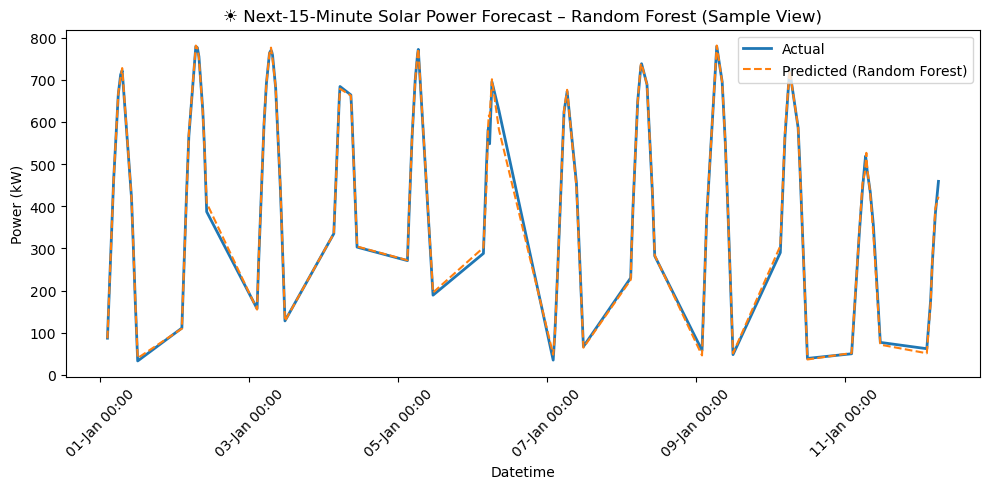

In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ✅ Ensure datetime column is in datetime format
df_forecast["datetime_next15"] = pd.to_datetime(df_forecast["datetime_next15"])

# ✅ Sort by datetime to prevent zigzag lines
df_forecast = df_forecast.sort_values(by="datetime_next15")

plt.figure(figsize=(10,5))

# Show first 100 samples after sorting
sample_df = df_forecast.head(100)

plt.plot(sample_df["datetime_next15"], sample_df["actual_next15_kW"], 
         label="Actual", linewidth=2)
plt.plot(sample_df["datetime_next15"], sample_df["pred_model_kW"], 
         label="Predicted (Random Forest)", linestyle="--")

plt.xlabel("Datetime")
plt.ylabel("Power (kW)")
plt.title("☀️ Next-15-Minute Solar Power Forecast – Random Forest (Sample View)")
plt.legend()

# ✅ Format x-axis for better readability
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Compare Baseline vs Model

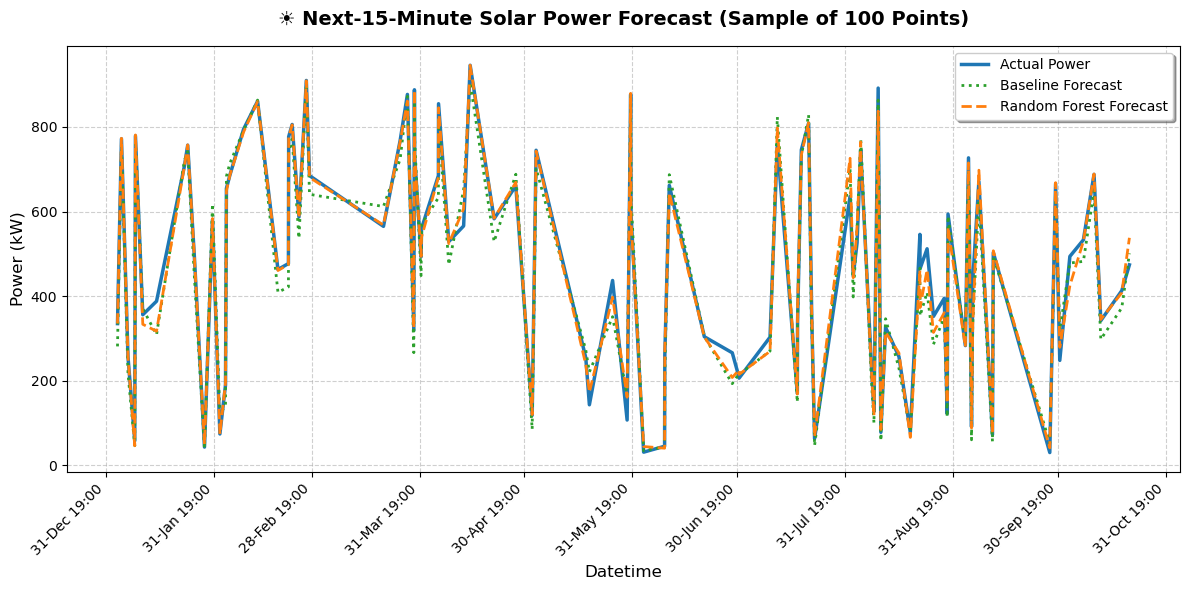

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Take a sample (first 100 records, or random if you prefer)
df_sample = df_forecast.sample(100, random_state=42).sort_values("datetime_next15")

# Create figure
plt.figure(figsize=(12,6))

# Plot actual values
plt.plot(df_sample["datetime_next15"], df_sample["actual_next15_kW"],
         label="Actual Power", color="#1f77b4", linewidth=2.5)

# Plot baseline predictions
plt.plot(df_sample["datetime_next15"], df_sample["pred_baseline_kW"],
         label="Baseline Forecast", color="#2ca02c", linestyle=":", linewidth=2)

# Plot Random Forest predictions
plt.plot(df_sample["datetime_next15"], df_sample["pred_model_kW"],
         label="Random Forest Forecast", color="#ff7f0e", linestyle="--", linewidth=2)

# Labels and title
plt.xlabel("Datetime", fontsize=12)
plt.ylabel("Power (kW)", fontsize=12)
plt.title("☀️ Next-15-Minute Solar Power Forecast (Sample of 100 Points)", 
          fontsize=14, fontweight="bold", pad=15)

# Date formatting on x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b %H:%M"))
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

# Grid for readability
plt.grid(True, linestyle="--", alpha=0.6)

# Legend with style
plt.legend(fontsize=10, frameon=True, shadow=True, loc="best")

# Optimize layout
plt.tight_layout()

# Show plot
plt.show()


## Feature Importance

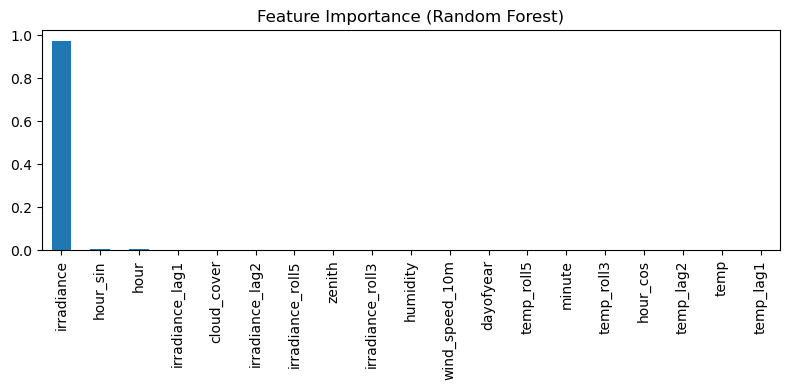

irradiance          0.974332
hour_sin            0.005905
hour                0.005836
irradiance_lag1     0.003505
cloud_cover         0.002030
irradiance_lag2     0.001346
irradiance_roll5    0.001212
zenith              0.001174
irradiance_roll3    0.001019
humidity            0.000815
wind_speed_10m      0.000786
dayofyear           0.000663
temp_roll5          0.000321
minute              0.000228
temp_roll3          0.000210
hour_cos            0.000197
temp_lag2           0.000146
temp                0.000144
temp_lag1           0.000129
dtype: float64


In [36]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=x_train.columns).sort_values(ascending=False)
feature_importance.plot(kind="bar", figsize=(8,4), title="Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

print(feature_importance)


In [37]:
print("✅ Phase 3 completed!")

print("""
Summary:
- We predicted solar plant output 15 minutes ahead using Random Forest.
- Model significantly improved over baseline.
- Graphs show strong alignment between actual and predicted.
- Feature importance indicates which weather variables most affect power.
- The project demonstrates an end-to-end ML pipeline:
  Data → Preprocessing → Modeling → Forecast → Visualization.
""")


✅ Phase 3 completed!

Summary:
- We predicted solar plant output 15 minutes ahead using Random Forest.
- Model significantly improved over baseline.
- Graphs show strong alignment between actual and predicted.
- Feature importance indicates which weather variables most affect power.
- The project demonstrates an end-to-end ML pipeline:
  Data → Preprocessing → Modeling → Forecast → Visualization.

